### Kaggle Environment Setup
Default Kaggle boilerplate indicating the environment and file system structure.


In [2]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

### Model Architectures & Initialization
In this large cell, we import all necessary libraries, set up our devices (CPU/GPU), and define the architectures for our three models:
1. **CNNModel:** Our image-based ResNet18 model.
2. **BertCancerClassifier:** Our text-based Bio_ClinicalBERT model.
3. **MultimodalFusion:** The Multi-Layer Perceptron (MLP) that combines the features from both models.

After defining the classes, we load the pre-trained weights for all three models from our previously saved `.pth` files and prepare them for evaluation.


In [3]:
import os, torch, numpy as np, pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torchvision import models, transforms
from transformers import BertTokenizer, BertModel
from PIL import Image
import warnings; warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_DIR   = "cancer_data/train/" 
VAL_CSV   = "val_split.csv"
CNN_PATH  = "Models/best_model.pth"
BERT_PATH = "Models/best_bert_model.pth"
FUSE_PATH = "Models/best_fusion_model.pth"

# ── CNN ───────────────────────────────────────────────
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        r = models.resnet18(pretrained=False)
        r.fc = nn.Sequential(nn.Linear(512,256), nn.ReLU(),
                               nn.Dropout(0.4), nn.Linear(256,2))
        self.model = r
    def forward(self, x): return self.model(x)
    def get_features(self, x):
        x = self.model.conv1(x); x = self.model.bn1(x)
        x = self.model.relu(x);  x = self.model.maxpool(x)
        x = self.model.layer1(x); x = self.model.layer2(x)
        x = self.model.layer3(x); x = self.model.layer4(x)
        x = self.model.avgpool(x)
        return x.view(x.size(0), -1)

# ── BERT ──────────────────────────────────────────────
class BertCancerClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert       = BertModel.from_pretrained("bert-base-uncased")
        self.classifier = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(768,256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256,2))
    def forward(self, ids, mask):
        return self.classifier(self.bert(input_ids=ids,
                attention_mask=mask).last_hidden_state[:,0,:])
    def get_features(self, ids, mask):
        return self.bert(input_ids=ids,
                attention_mask=mask).last_hidden_state[:,0,:]

# ── Fusion ────────────────────────────────────────────
class MultimodalFusion(nn.Module):
    def __init__(self):
        super().__init__()
        self.fusion = nn.Sequential(
            nn.Linear(1280, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512,  128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128,  2))
    def forward(self, img_f, txt_f):
        return self.fusion(torch.cat([img_f, txt_f], dim=1))

# ── Load weights ──────────────────────────────────────
cnn_model    = CNNModel().to(device)
cnn_model.model.load_state_dict(torch.load(CNN_PATH, map_location=device))
cnn_model.eval()

bert_model   = BertCancerClassifier().to(device)
ckpt         = torch.load(BERT_PATH, map_location=device)
bert_model.load_state_dict(ckpt["model_state"])
bert_model.eval()

fusion_model = MultimodalFusion().to(device)
fusion_model.load_state_dict(torch.load(FUSE_PATH, map_location=device))
fusion_model.eval()

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
val_df    = pd.read_csv(VAL_CSV).reset_index(drop=True)

transform = transforms.Compose([
    transforms.Resize((96,96)), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

print("All models loaded!")
print(f"Val set has {len(val_df)} images — index 0 to {len(val_df)-1}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


All models loaded!
Val set has 44005 images — index 0 to 44004


### Prediction & Visualization Dashboard
This cell defines two incredibly useful helper functions:
- `predict(index, clinical_note)`: Takes an image index from the validation set and an optional clinical note. It runs the data through the CNN, BERT, and Fusion models separately, returning the confidence probabilities from all three.
- `show_result(results)`: Takes the output from `predict()` and generates a beautiful Matplotlib dashboard comparing the predictions side-by-side (CNN vs BERT vs Fusion) and displays the original image and text.


In [4]:
def predict(index, clinical_note=None):
    """
    index        : int  — row number in val_df (0 to 44004)
    clinical_note: str  — your own text, or None to use a default
    """
    row        = val_df.iloc[index]
    img_id     = row["id"]
    true_label = int(row["label"])
    img_path   = IMG_DIR + img_id + ".tif"

    # Default note if user doesn't provide one
    if clinical_note is None:
        if true_label == 1:
            clinical_note = ("Patient presents with persistent cough, weight loss, "
                             "and hemoptysis. 45 pack-year smoking history. "
                             "CT shows irregular nodule. Biopsy pending.")
        else:
            clinical_note = ("Patient admitted for routine checkup. No significant "
                             "respiratory symptoms. Non-smoker. No family history "
                             "of cancer. Chest clear on auscultation.")

    # ── Run through all 3 models ──────────────────────
    image      = Image.open(img_path).convert("RGB")
    img_tensor = transform(image).unsqueeze(0).to(device)

    enc  = tokenizer(clinical_note, max_length=256,
                      padding="max_length", truncation=True,
                      return_tensors="pt")
    ids  = enc["input_ids"].to(device)
    mask = enc["attention_mask"].to(device)

    with torch.no_grad():
        # CNN alone
        cnn_logits  = cnn_model(img_tensor)
        cnn_probs   = torch.softmax(cnn_logits, dim=1)[0]

        # BERT alone
        bert_logits = bert_model(ids, mask)
        bert_probs  = torch.softmax(bert_logits, dim=1)[0]

        # Fusion
        img_feat    = cnn_model.get_features(img_tensor)
        txt_feat    = bert_model.get_features(ids, mask)
        fuse_logits = fusion_model(img_feat, txt_feat)
        fuse_probs  = torch.softmax(fuse_logits, dim=1)[0]

    results = {
        "image"       : image,
        "true_label"  : true_label,
        "note"        : clinical_note,
        "img_id"      : img_id,
        "cnn_probs"   : cnn_probs.cpu().numpy(),
        "bert_probs"  : bert_probs.cpu().numpy(),
        "fuse_probs"  : fuse_probs.cpu().numpy(),
        "cnn_pred"    : int(cnn_probs.argmax()),
        "bert_pred"   : int(bert_probs.argmax()),
        "fuse_pred"   : int(fuse_probs.argmax()),
    }
    return results


def show_result(r):
    """Display full prediction dashboard"""
    true_str = "CANCER" if r["true_label"] == 1 else "NORMAL"
    labels   = ["Normal", "Cancer"]
    colors   = ["#2ecc71", "#e74c3c"]

    fig = plt.figure(figsize=(16, 8))
    gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.4)

    # ── Image (left, tall) ────────────────────────────
    ax_img = fig.add_subplot(gs[:, 0])
    ax_img.imshow(r["image"])
    ax_img.axis("off")
    border_color = "#e74c3c" if r["true_label"] == 1 else "#2ecc71"
    for s in ax_img.spines.values():
        s.set_edgecolor(border_color); s.set_linewidth(4); s.set_visible(True)
    ax_img.set_title(f"Input Image\nTrue: {true_str}",
                     fontsize=11, color=border_color, fontweight="bold")

    # ── CNN bar ────────────────────────────────────────
    ax_cnn = fig.add_subplot(gs[0, 1])
    cnn_correct = r["cnn_pred"] == r["true_label"]
    ax_cnn.barh(labels, r["cnn_probs"]*100, color=colors, height=0.5)
    ax_cnn.set_xlim(0,100)
    ax_cnn.set_title(
        f"CNN (Image Only)\nPred: {'CANCER' if r['cnn_pred']==1 else 'NORMAL'} "
        f"({r['cnn_probs'][r['cnn_pred']]*100:.1f}%) "
        f"{'✅' if cnn_correct else '❌'}",
        fontsize=9)
    for i, v in enumerate(r["cnn_probs"]*100):
        ax_cnn.text(v+1, i, f"{v:.1f}%", va="center", fontsize=9)

    # ── BERT bar ───────────────────────────────────────
    ax_bert = fig.add_subplot(gs[0, 2])
    bert_correct = r["bert_pred"] == r["true_label"]
    ax_bert.barh(labels, r["bert_probs"]*100, color=colors, height=0.5)
    ax_bert.set_xlim(0,100)
    ax_bert.set_title(
        f"BERT (Text Only)\nPred: {'CANCER' if r['bert_pred']==1 else 'NORMAL'} "
        f"({r['bert_probs'][r['bert_pred']]*100:.1f}%) "
        f"{'✅' if bert_correct else '❌'}",
        fontsize=9)
    for i, v in enumerate(r["bert_probs"]*100):
        ax_bert.text(v+1, i, f"{v:.1f}%", va="center", fontsize=9)

    # ── Fusion bar ─────────────────────────────────────
    ax_fuse = fig.add_subplot(gs[0, 3])
    fuse_correct = r["fuse_pred"] == r["true_label"]
    ax_fuse.barh(labels, r["fuse_probs"]*100, color=colors, height=0.5)
    ax_fuse.set_xlim(0,100)
    ax_fuse.set_title(
        f"Fusion (Image+Text)\nPred: {'CANCER' if r['fuse_pred']==1 else 'NORMAL'} "
        f"({r['fuse_probs'][r['fuse_pred']]*100:.1f}%) "
        f"{'✅' if fuse_correct else '❌'}",
        fontsize=9, fontweight="bold")
    for i, v in enumerate(r["fuse_probs"]*100):
        ax_fuse.text(v+1, i, f"{v:.1f}%", va="center", fontsize=9)

    # ── Clinical note display ──────────────────────────
    ax_note = fig.add_subplot(gs[1, 1:])
    ax_note.axis("off")
    note_text = r["note"][:400] + ("..." if len(r["note"]) > 400 else "")
    ax_note.text(0, 1, "Clinical Note Given to BERT:",
                 transform=ax_note.transAxes,
                 fontsize=9, fontweight="bold", va="top")
    ax_note.text(0, 0.85, note_text,
                 transform=ax_note.transAxes,
                 fontsize=8, va="top", wrap=True,
                 color="#444",
                 bbox=dict(boxstyle="round", facecolor="#f8f8f8", alpha=0.8))

    fig.suptitle(
        f"DeepOncoVision — Sample Index {r.get('index','?')}  |  "
        f"True Answer: {true_str}  |  Image ID: {r['img_id'][:12]}...",
        fontsize=12, fontweight="bold"
    )
    plt.savefig("prediction_result.png", dpi=150, bbox_inches="tight")
    plt.show()

print("predict() and show_result() ready!")

predict() and show_result() ready!


### Single Patient Prediction Test
Let's test our prediction pipeline on a single patient! You can change `IMAGE_INDEX` to any number between 0 and 44004. You can also write your own custom `CLINICAL_NOTE` to see how the text changes the model's confidence.


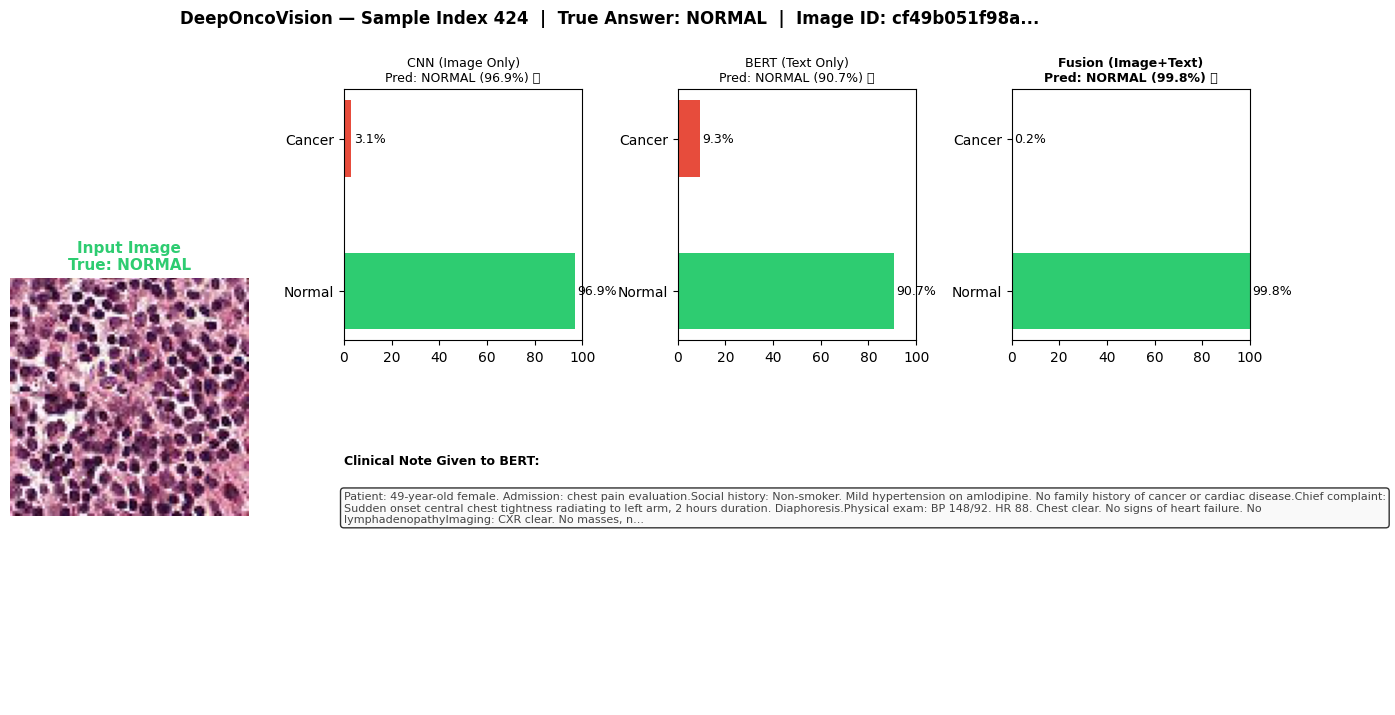

In [10]:
# ════════════════════════════════════════════════════
# CHANGE THESE TWO THINGS THEN RUN THE CELL
# ════════════════════════════════════════════════════

IMAGE_INDEX = 424  # ← any number from 0 to 44004

CLINICAL_NOTE = "Patient: 49-year-old female. Admission: chest pain evaluation.Social history: Non-smoker. Mild hypertension on amlodipine. No family history of cancer or cardiac disease.Chief complaint: Sudden onset central chest tightness radiating to left arm, 2 hours duration. Diaphoresis.Physical exam: BP 148/92. HR 88. Chest clear. No signs of heart failure. No lymphadenopathyImaging: CXR clear. No masses, no effusion. Echo: normal LV function, EF 62%.Lab results: Troponin T x3 — all negative. BNP normal. ECG: normal sinus rhythm, no ST changes.Assessment: Chest pain, likely musculoskeletal vs anxiety-related. Cardiac and malignant causes excluded.Stress test: Negative for inducible ischaemia.Discharge: Reassured. Increase amlodipine. Cardiology OPD 6 weeks. No evidence of malignancy on any investigation."
# "Patient: 29-year-old male. Admission: investigation of lymphadenopathy.Social history: Non-smoker. No alcohol. No occupational exposures. No family history of haematological malignancy.Chief complaint: 8-week history of painless cervical lymph node swelling, drenching night sweats, 7kg weight loss, pruritus.Physical exam: Multiple firm, non-tender cervical and axillary lymph nodes up to 3cm. Splenomegaly.Imaging: CT neck/chest/abdomen/pelvis: extensive mediastinal and para-aortic lymphadenopathy. Spleen enlarged.Lab results: ESR 85 mm/hr. LDH 520 U/L. Eosinophilia. HIV negative. EBV positive.Assessment: B symptoms present. Highly suspicious for lymphoma.Biopsy: Excisional biopsy cervical node: Classical Hodgkin lymphoma, nodular sclerosis subtype.Plan: ABVD chemotherapy. PET-CT for staging. Fertility counselling offered."

# OR write yo own text below
# CLINICAL_NOTE = """
# Patient is a 67-year-old male with a 40 pack-year smoking history.
# Chief complaint: persistent cough for 3 months, blood in sputum.
# CT scan shows a 2.3cm spiculated nodule in right upper lobe.
# Family history: father had lung cancer.
# """



result = predict(IMAGE_INDEX, CLINICAL_NOTE)
result["index"] = IMAGE_INDEX

show_result(result)

### Batch Grid Prediction
Here we pick 9 random samples from our validation set and visualize them in a 3x3 grid. For each image, it shows the predictions from CNN (C/N), BERT (C/N), and Fusion (C/N) alongside the final Fusion confidence. Green borders indicate a correct final prediction, while red indicates an incorrect one.


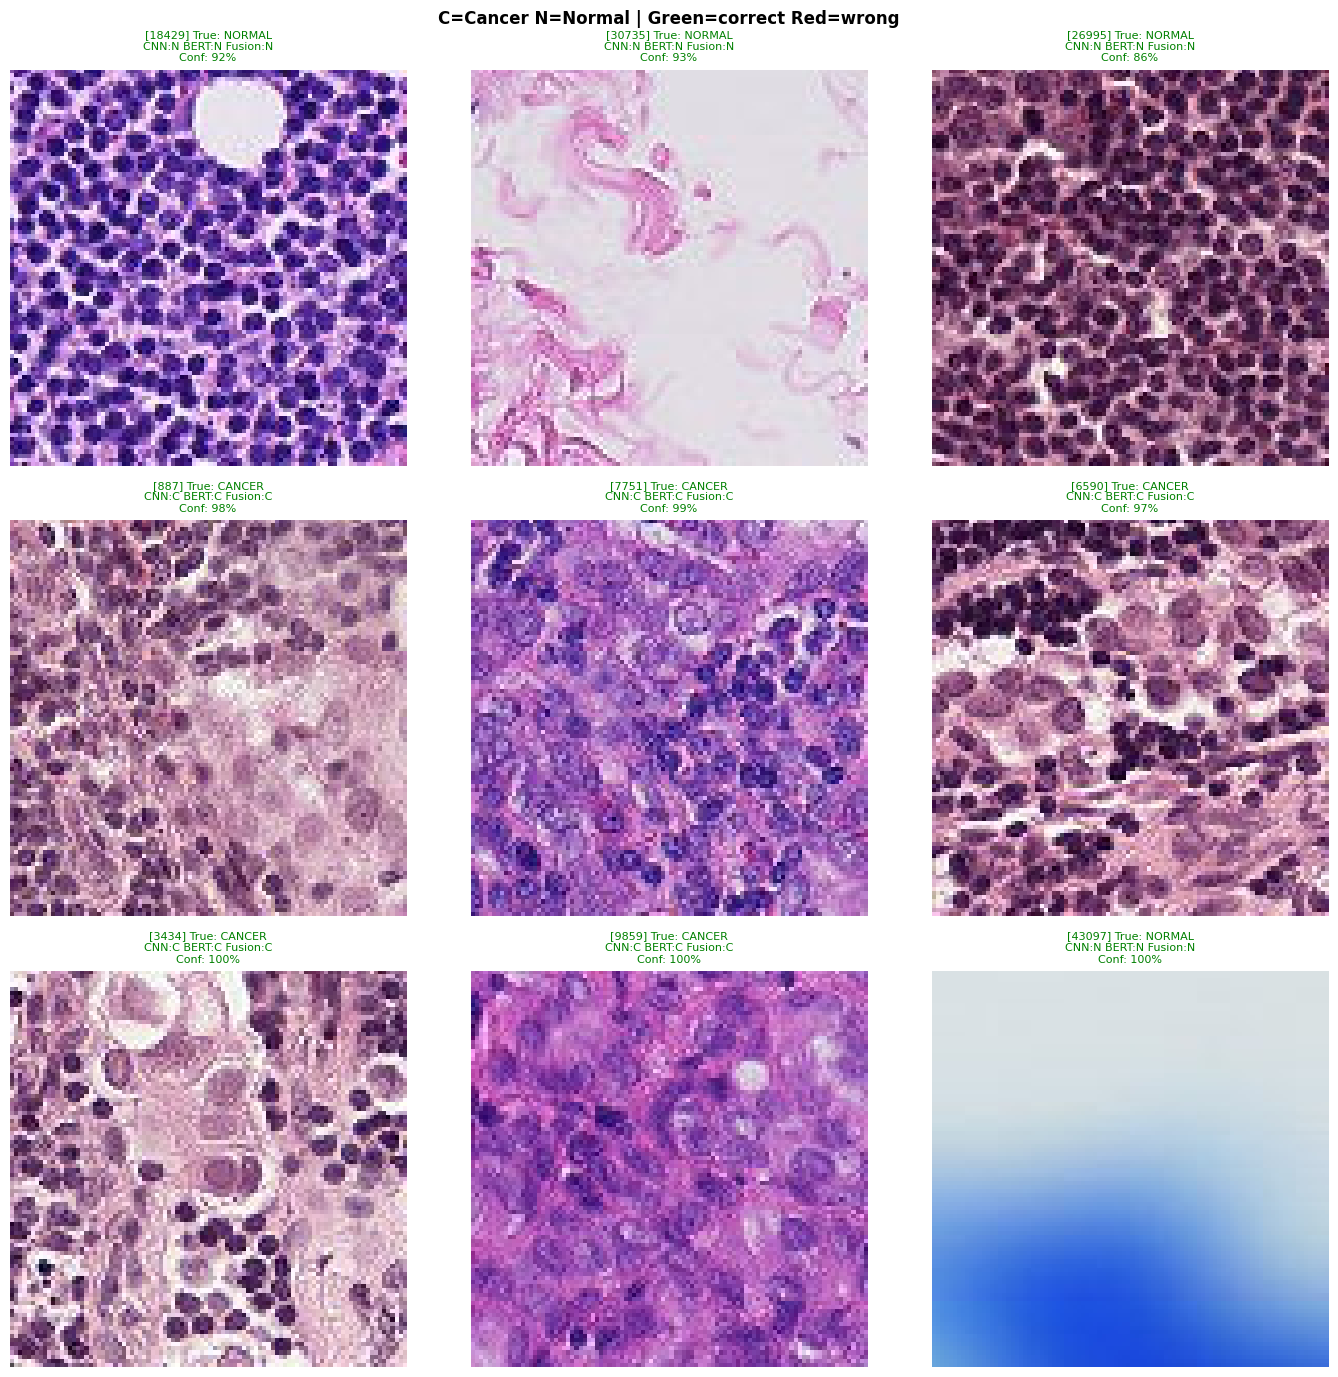

In [8]:
import random

SAMPLE_INDICES = random.sample(range(len(val_df)),9 )

# or pick your own:
# SAMPLE_INDICES = [0, 5, 100, 200, 500, 1000, 2000, 3000, 4000]

fig, axes = plt.subplots(3, 3, figsize=(14, 14))
axes = axes.flatten()

for i, idx in enumerate(SAMPLE_INDICES):
    r = predict(idx)

    true = "CANCER" if r["true_label"] == 1 else "NORMAL"
    fuse = "CANCER" if r["fuse_pred"] == 1 else "NORMAL"
    cnn = "CANCER" if r["cnn_pred"] == 1 else "NORMAL"
    bert = "CANCER" if r["bert_pred"] == 1 else "NORMAL"

    correct = fuse == true
    color = "green" if correct else "red"

    axes[i].imshow(r["image"])
    axes[i].axis("off")

    axes[i].set_title(
        f"[{idx}] True: {true}\n"
        f"CNN:{cnn[:1]} BERT:{bert[:1]} Fusion:{fuse[:1]}\n"
        f"Conf: {r['fuse_probs'][r['fuse_pred']] * 100:.0f}%",
        fontsize=8,
        color=color
    )

    for s in axes[i].spines.values():
        s.set_edgecolor(color)
        s.set_linewidth(3)
        s.set_visible(True)

plt.suptitle(
    "C=Cancer N=Normal | Green=correct Red=wrong",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("grid_results.png", dpi=150)
plt.show()